Epoch 1, Loss: 1.0624
Epoch 2, Loss: 1.0506
Epoch 3, Loss: 1.0268
Epoch 4, Loss: 1.0076
Epoch 5, Loss: 0.9867
Epoch 6, Loss: 0.9541
Epoch 7, Loss: 0.9109
Epoch 8, Loss: 0.8639
Epoch 9, Loss: 0.8128
Epoch 10, Loss: 0.7610
Epoch 11, Loss: 0.7123
Epoch 12, Loss: 0.6649
Epoch 13, Loss: 0.6134
Epoch 14, Loss: 0.5706
Epoch 15, Loss: 0.5322
Epoch 16, Loss: 0.4982
Epoch 17, Loss: 0.4689
Epoch 18, Loss: 0.4485
Epoch 19, Loss: 0.4290
Epoch 20, Loss: 0.4140
Epoch 21, Loss: 0.4029
Epoch 22, Loss: 0.3907
Epoch 23, Loss: 0.3811
Epoch 24, Loss: 0.3739
Epoch 25, Loss: 0.3648
Epoch 26, Loss: 0.3565
Epoch 27, Loss: 0.3474
Epoch 28, Loss: 0.3383
Epoch 29, Loss: 0.3295
Epoch 30, Loss: 0.3198
Epoch 31, Loss: 0.3115
Epoch 32, Loss: 0.3006
Epoch 33, Loss: 0.2909
Epoch 34, Loss: 0.2800
Epoch 35, Loss: 0.2706
Epoch 36, Loss: 0.2594
Epoch 37, Loss: 0.2493
Epoch 38, Loss: 0.2391
Epoch 39, Loss: 0.2294
Epoch 40, Loss: 0.2194
Epoch 41, Loss: 0.2102
Epoch 42, Loss: 0.2020
Epoch 43, Loss: 0.1927
Epoch 44, Loss: 0.18

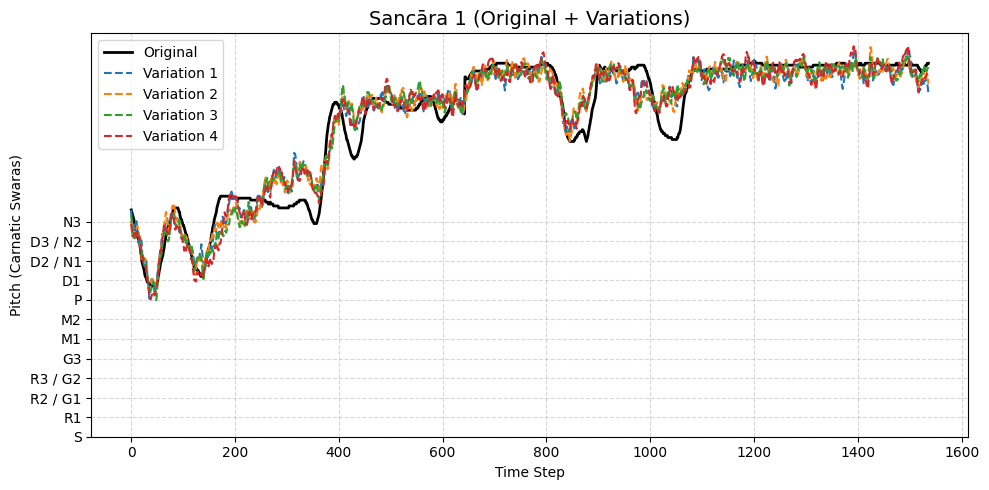

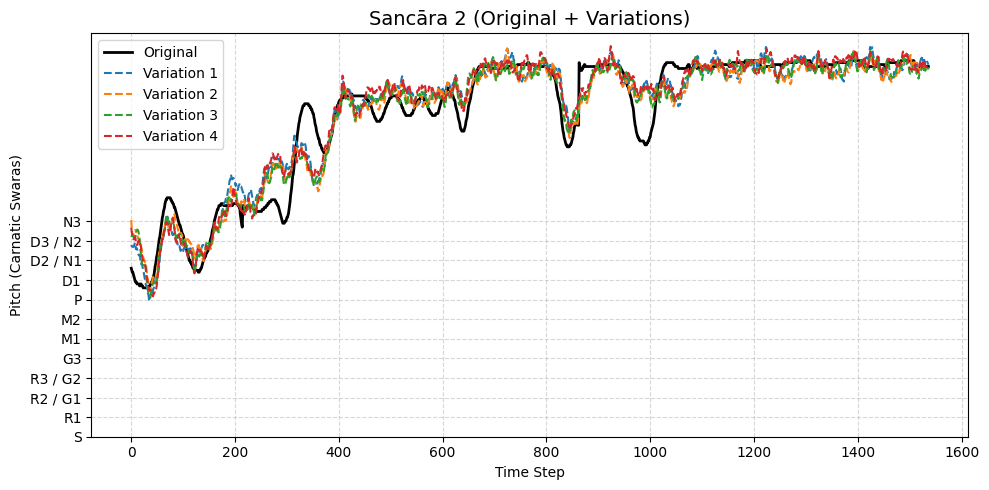

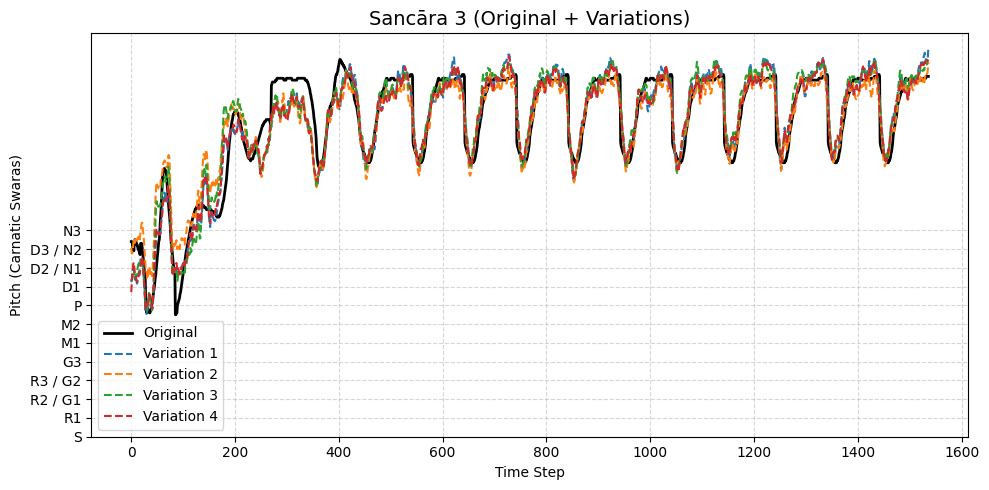

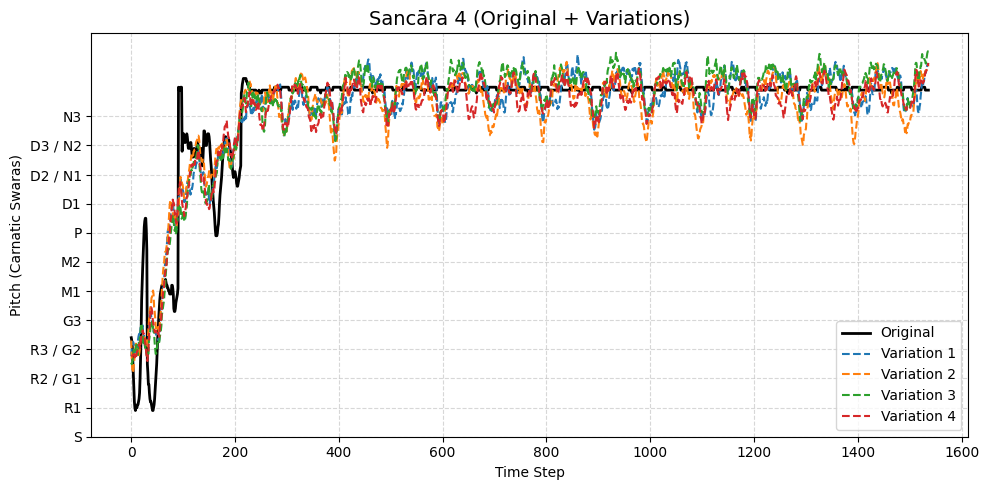

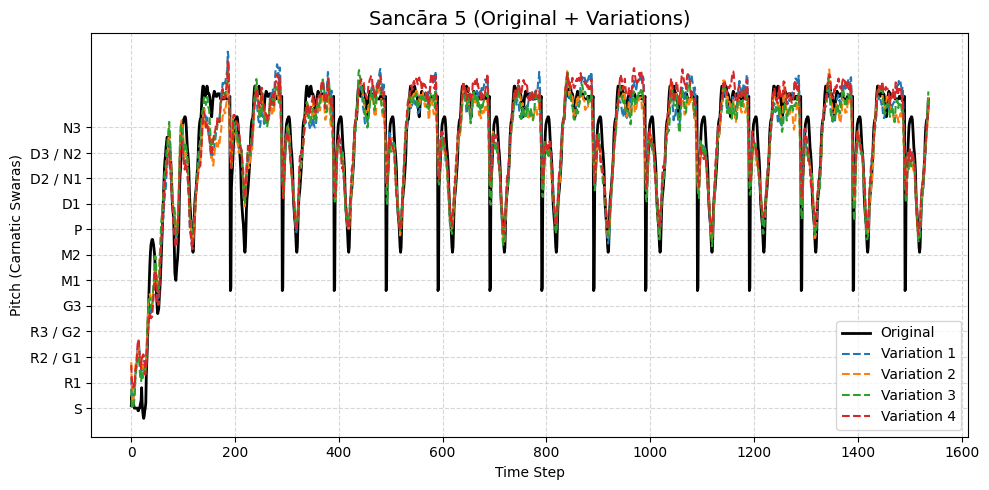

In [2]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from scipy.signal import savgol_filter

# ====================== Load and Normalize ======================
with open("/content/only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)


def pad_with_last_100_pitches(sequences):
    max_len = max(len(seq) for seq in sequences)
    padded_sequences = []

    for seq in sequences:
        if len(seq) < max_len:
            last_100 = seq[-100:] if len(seq) >= 100 else seq  # If less than 100, take as much as possible
            repeats = (max_len - len(seq)) // len(last_100)
            remainder = (max_len - len(seq)) % len(last_100)

            padding = torch.cat([last_100] * repeats + [last_100[:remainder]])
            padded_seq = torch.cat([seq, padding])
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)
padded_phrases = pad_with_last_100_pitches(phrases)
mean = padded_phrases[padded_phrases != 0].mean()
std = padded_phrases[padded_phrases != 0].std()
padded_phrases = (padded_phrases - mean) / std

# ====================== Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.data = phrases

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = PhraseDataset(padded_phrases)

# ====================== VAE Model ======================
class VAE(nn.Module):
    def __init__(self, seq_len, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ====================== Loss Function ======================
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * kl_div  # Beta-VAE

# ====================== Train (Full-Batch) ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = padded_phrases.shape[1]
model = VAE(seq_len=seq_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

full_batch = padded_phrases.to(device)

model.train()
for epoch in range(100):
    recon, mu, logvar = model(full_batch)
    loss = vae_loss(recon, full_batch, mu, logvar)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# ====================== Helpers ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

# ====================== Generate Variations ======================
def generate_variation_from_phrase(model, input_tensor, num_variants=5, variation_strength=0.5):
    model.eval()
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        mu, logvar = model.encode(input_tensor.unsqueeze(0))
        variations = []
        for _ in range(num_variants):
            z = mu + variation_strength * torch.randn_like(mu)
            out = model.decode(z).squeeze(0)
            out = out.cpu().numpy() * std.item() + mean.item()
            out = smooth(out)
            out = clip_pitch_range(out)
            variations.append(out)
        return variations

import numpy as np
import matplotlib.pyplot as plt

# Function to map pitch values (in cents) to Carnatic music note names
def pitch_to_carnatic_note_name(pitch):
    """Convert pitch value in cents to Carnatic music note name."""
    # Note names based on standard Carnatic music notation
    cent_intervals = np.arange(0, 1200, 100)
    swaras = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    idx = int(round(pitch / 100))
    if 0 <= idx < len(swaras):
        return swaras[idx]
    return ''

# ====================== Plot Variations ======================
num_phrases_to_plot = 5  # Number of phrases to visualize

for idx in range(num_phrases_to_plot):
    input_phrase = dataset[idx]
    original = input_phrase.numpy() * std.item() + mean.item()
    variants = generate_variation_from_phrase(model, input_phrase, num_variants=4, variation_strength=0.4)

    plt.figure(figsize=(10, 5))
    plt.plot(original, label="Original", linewidth=2, color="black")
    for i, var in enumerate(variants):
        plt.plot(var, label=f"Variation {i+1}", linestyle="--")
    plt.title(f"Sancāra {idx + 1} (Original + Variations)", fontsize=14)
    plt.xlabel("Time Step")
    plt.ylabel("Pitch (Carnatic Swaras)")
        # Set Y-ticks every 100 cents with Carnatic swara labels
    y_ticks = np.arange(0, 1200, 100)
    y_labels = ['S', 'R1', 'R2 / G1', 'R3 / G2', 'G3', 'M1', 'M2', 'P', 'D1', 'D2 / N1', 'D3 / N2', 'N3']
    plt.yticks(y_ticks, y_labels)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()